# 1. Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("C:/Users/akash/OneDrive/Desktop/AKASH BHAI FILE/Projects/Excel Cleaning/clean_retail.csv")

# 2. Data Overviews

In [5]:
df.info()
df.isna().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
dtype: int64

# 3. KPI Summary

In [6]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
loss_orders = (df["Profit"]<0).sum()
loss_pct = loss_orders/len(df)*100

total_sales, total_profit, loss_orders, loss_pct

(np.float64(2297200.8603),
 np.float64(286397.0217),
 np.int64(1871),
 np.float64(18.721232739643785))

# 4. Category Profit Visualization

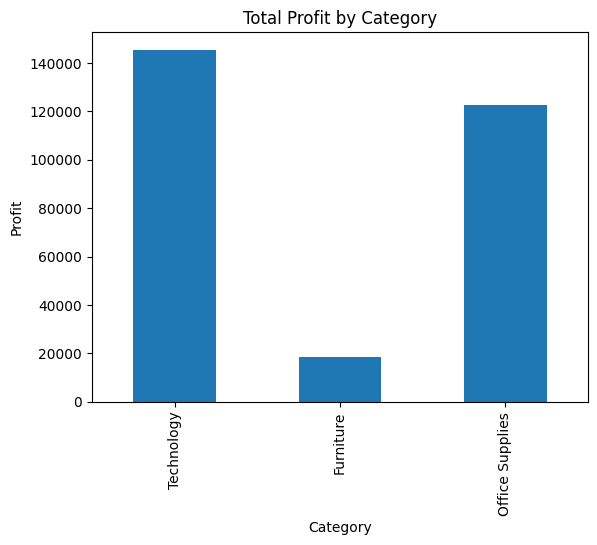

In [7]:
cat = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
cat
cat["Profit"].plot(kind= "bar")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

**Insight**: Furniture category making less profit as comparison of Technology and Office Supplies.

# 5. Discount vs Profit Relationship

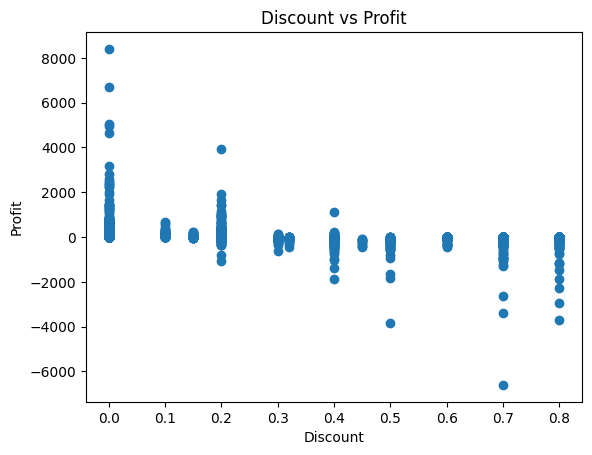

In [8]:
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

**Insights**: Higher discount levels strongly correlate with lower profit.

# 6. Worst Sub-Categories

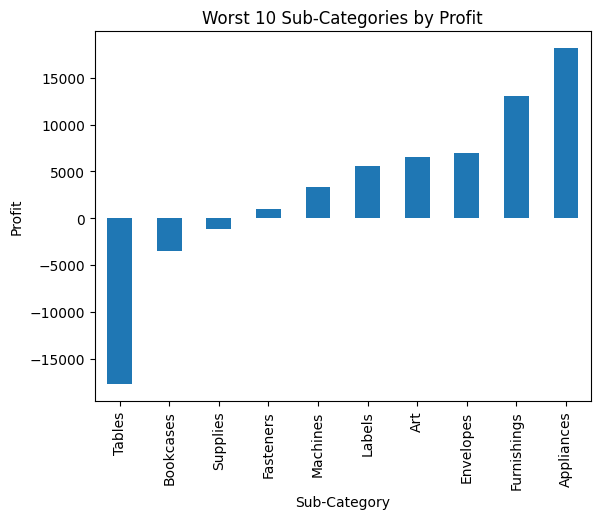

In [10]:
worst = df.groupby("Sub-Category")["Profit"].sum().sort_values().head(10)
worst
worst.plot(kind = "bar")
plt.title("Worst 10 Sub-Categories by Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.show()

**Insights**: Profit distribution varies significantly across product categories. But Tables, Bookcases and Supplies are making loss to company.

# 7. Monthly Sales Trend

In [13]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst=True, errors="coerce")

In [14]:
df["Order Month"] = df["Order Date"].dt.to_period("M")

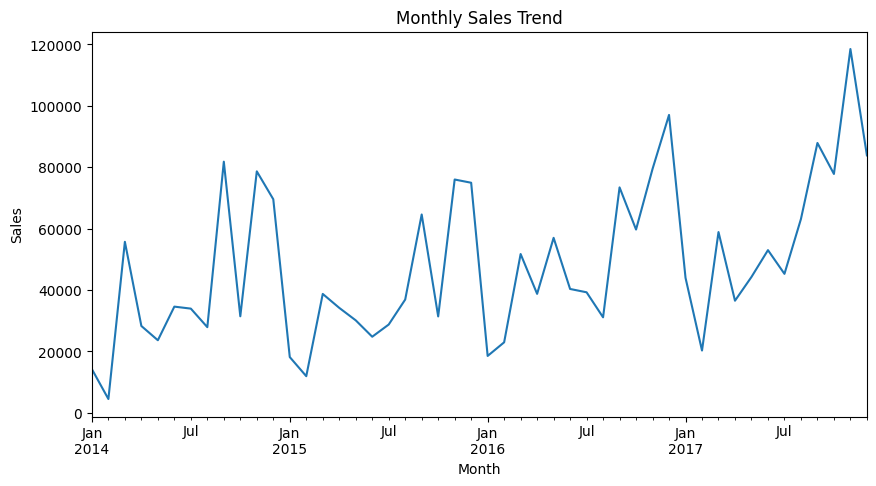

In [15]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**Insights**: Sales fluctuate month-to-month but show an increasing yearly trend.

# 8. Profit Margin Analysis

In [18]:
df.groupby("Category")["Profit Margin"].mean().sort_values(ascending=False)

Category
Technology         275719.925907
Office Supplies     37154.179866
Furniture           14915.705752
Name: Profit Margin, dtype: float64

**Insight**: Technology products maintain the strongest profit margin.